# Best Subset Selection

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1. Load the Dataset and Inspect

The dataset that will be used is `load_diabetes` dataset from sklearn library. This dataset has 10 features.

In [43]:
diabetes = load_diabetes(as_frame=True)

X = diabetes.data
y = diabetes.target

df = pd.DataFrame(X, columns=load_diabetes().feature_names)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


### 1.1 Dataset Shape

In this dataset we have:
- 442 samples.
- 11 attributes (10 of are features and 1 is target)

In [44]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (442, 11)


### 1.2 Dataset Info

- No missing values.
- No qualitative attribute meaning no need for encoders.
- The need of a scaler is not yet been justfied.

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


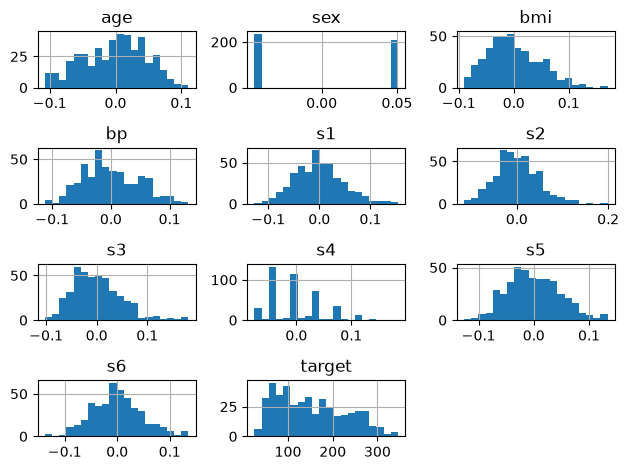

In [46]:
df.hist(bins=20)
plt.tight_layout()
plt.show();

In [47]:
df[df['sex'] > 0].head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.05068,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
2,0.085299,0.05068,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
6,-0.045472,0.05068,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062917,-0.038357,138.0
7,0.063504,0.05068,-0.001895,0.066629,0.090620,0.108914,0.022869,0.017703,-0.035816,0.003064,63.0
8,0.041708,0.05068,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014960,0.011349,110.0


## 2. Split dataset

`train_test_split()` will be used to split the dataset 

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED
)

## 3. Implement Best Subset Selection Algorithm

### 3.1 Test itertools.conbinations First

This can be used to generate conbinations of an iterable.

In [49]:
items = ['A', 'B', 'C']
numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9]

iterator = combinations(numbers, 2)

# print(list(iterator))
# for subset in list(iterator):
#     print(subset)

### 3.2 Implement Best Subset Selection Algorithm

- **RSS**: an error metric that measures the total squared difference between the actual data values and the values predicted by a regression model.

In [52]:
results = []
for k in range(1, X_train.shape[1] + 1):
    rss = []
    for subset in combinations(X_train.columns, k):

        model = LinearRegression()
        model.fit(X_train[list(subset)], y_train)
        y_pred = model.predict(X_train[list(subset)])

        subset_rss = ((y_train - y_pred) ** 2).sum()

        rss.append((subset_rss, subset))

    results.append(min(rss, key=lambda x: x[0]))

In [58]:
for i, result in enumerate(results):
    print(f"({i}) RSS: {result[0]}, {result[1]}")

(0) RSS: 1360501.7661827644, ('bmi',)
(1) RSS: 1161834.7519467813, ('bmi', 's5')
(2) RSS: 1108649.5035964558, ('bmi', 'bp', 's5')
(3) RSS: 1074425.5272317054, ('bmi', 'bp', 's1', 's5')
(4) RSS: 1040983.5653990463, ('sex', 'bmi', 'bp', 's3', 's5')
(5) RSS: 1022172.2639890872, ('sex', 'bmi', 'bp', 's1', 's2', 's5')
(6) RSS: 1016695.1037401557, ('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5')
(7) RSS: 1015027.3246336153, ('sex', 'bmi', 'bp', 's1', 's2', 's4', 's5', 's6')
(8) RSS: 1013490.0819656126, ('sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')
(9) RSS: 1012598.0451009589, ('age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6')


### 3.3 Plot RSS Values

10
range(1, 11)


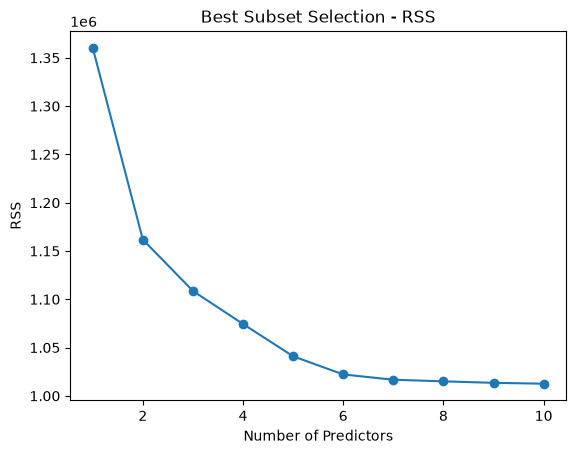

In [70]:
rss_values = [x[0] for x in results]
print(len(rss_values))
model_sizes = range(1, len(results) + 1)
print(model_sizes)

plt.plot(model_sizes, rss_values, marker="o")
plt.xlabel("Number of Predictors")
plt.ylabel("RSS")
plt.title("Best Subset Selection - RSS")
plt.show();

#### Notes

RSS continuously decreases because increasing model size gives the model greater flexibility. Therefore training RSS alone cannot determine the optimal model size.

This was also pointed out in textbook "An Introduction to Statistical Learning"

### 3.4 Adjusted R-Squared

**R-squared** is a statistical measure that represent the goodness of fit of a regression model.

- The value of R-square lies between 0 to 1.
- Where we get R-square equals 1 when the model perfectly fits the data.
- 0 when the model does not predict any variability in the model.

#### 3.4.1 How is R-Squared Calculate

1. calculate the mean of the target/dependent variable y_mean.
2. Calculate the total sum of squares by subtracting each observation y_i from y_mean, then squaring it and summing these square differences across all the values.
3. We calculate the sum of squares. It explains unaccounted variability in the dependent y after predicting these values from an independent variable in the model.

In [71]:
def r_squared(y, y_pred):
    # Calculate Residual sum of squares
    ss_res = np.sum((y - y_pred) ** 2)

    # calculate total sum of squares
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r_squared_val = 1 - (ss_res / ss_tot)

    return r_squared_val

In [72]:
def adjusted_r_squared(y, y_pred, n, k):
    n = y.shape[0]
    return 1 - ((1 - r_squared(y, y_pred)) * (n - 1)) / (n - k - 1)